In [1]:
!pip -q install torch torchvision scikit-learn xgboost imbalanced-learn tqdm pillow pandas numpy




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Global path



🚀 Running Ablation for RNA...
T=1  → Acc=0.737
T=2  → Acc=0.754
T=3  → Acc=0.580
T=4  → Acc=0.621
T=5  → Acc=0.545

🚀 Running Ablation for DNA...
T=1  → Acc=0.617
T=2  → Acc=0.611
T=3  → Acc=0.578
T=4  → Acc=0.566
T=5  → Acc=0.554
T=7  → Acc=0.602

🚀 Running Ablation for MRI...
T=4  → Acc=0.333
T=6  → Acc=0.330
T=8  → Acc=0.340
T=10 → Acc=0.332
T=12 → Acc=0.336


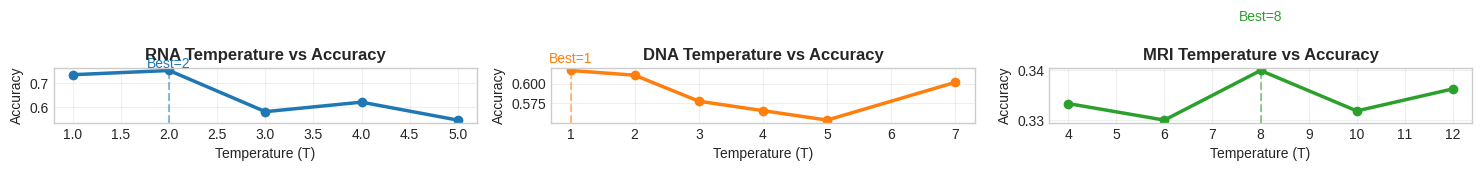

/tmp/ipython-input-3013627958.py:282: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(best_Ts.keys()), y=list(best_Acc.values()), palette=colors.values())


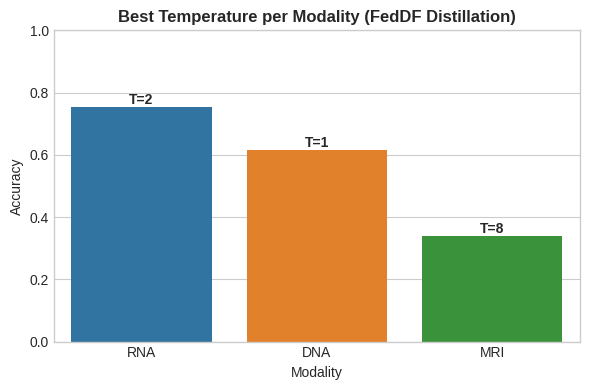


🏆 Optimal Temperatures:
RNA: T=2 → Acc=0.754
DNA: T=1 → Acc=0.617
MRI: T=8 → Acc=0.340


In [2]:
import os, random, gc, numpy as np, pandas as pd
from glob import glob
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from scipy.ndimage import gaussian_filter1d

# 0. Configuration
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Paths for each modality
DATA_RNA = "/content/drive/MyDrive/5703/RNA_cleaned.csv"
DATA_DNA = "/content/drive/MyDrive/5703/ADNI3_DNA_cleaned.csv"
DATA_MRI = "/content/drive/MyDrive/5703/FL/Sampled MRI"

N_CLASSES = 3  # number of diagnostic categories

# Hyperparameters for distillation
T_RNA, T_DNA, T_MRI = 3.0, 1.0, 8.0       # temperature per modality
ALPHA_RNA, ALPHA_DNA, ALPHA_MRI = 0.8, 0.7, 0.7  # soft/hard loss ratio
W_RNA, W_DNA, W_MRI = 0.6, 1.5, 1.2       # loss weighting
EPOCHS_STUDENT = 40                       # training epochs
LR_STUDENT = 3e-4                         # student learning rate
HIDDEN_DIM = 256                          # shared hidden size

# CNN hyperparameters for MRI branch
MRI_LR = 7.354e-5
MRI_DROPOUT = 0.2
MRI_IMG_SIZE = (224, 224)

# 1. RNA Client (Teacher)
df_rna = pd.read_csv(DATA_RNA)
Xr = df_rna.drop(columns=["DIAGNOSIS","subject_id"], errors='ignore')
yr = df_rna["DIAGNOSIS"].astype(int)

# Encode class labels
le_rna = LabelEncoder(); yr_enc = le_rna.fit_transform(yr)

# Split into train/test
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr_enc, test_size=0.3, stratify=yr_enc, random_state=SEED)

# Standardize features
sc_rna = StandardScaler().fit(Xr_train)
Xr_train = sc_rna.transform(Xr_train).astype(np.float32)
Xr_test  = sc_rna.transform(Xr_test ).astype(np.float32)

# Define a simple 3-layer MLP for RNA classification
class RNA_MLP(nn.Module):
    def __init__(self,in_dim,n_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

# Train RNA teacher
rna_client = RNA_MLP(Xr_train.shape[1],N_CLASSES).to(device)
opt_rna = torch.optim.Adam(rna_client.parameters(), lr=1e-3)
ce = nn.CrossEntropyLoss()

for _ in range(12):
    rna_client.train()
    out = rna_client(torch.tensor(Xr_train,device=device))
    loss = ce(out, torch.tensor(yr_train,device=device))
    opt_rna.zero_grad(); loss.backward(); opt_rna.step()

# Evaluate RNA teacher
rna_client.eval()
with torch.no_grad():
    logits_rna = rna_client(torch.tensor(Xr_test,device=device))
    y_pred_rna_t = logits_rna.argmax(1).cpu().numpy()
    p_rna_soft = F.softmax(logits_rna/T_RNA,dim=1).cpu().numpy()

# Record RNA teacher performance
acc_rna_teacher = accuracy_score(yr_test, y_pred_rna_t)
f1_rna_teacher = f1_score(yr_test, y_pred_rna_t, average='weighted')

# Free memory
del rna_client, opt_rna, out, loss; gc.collect()

# 2. DNA Client (Teacher)
dna = pd.read_csv(DATA_DNA).drop(columns=["PTID","EXAMDATE","PHASE"], errors='ignore')
Xd = dna.drop(columns=["DIAGNOSIS"],errors='ignore').select_dtypes(include=[np.number])
yd = dna["DIAGNOSIS"].astype(int)

# Encode labels
le_dna = LabelEncoder(); yd_enc = le_dna.fit_transform(yd)

# Split and standardize
Xd_train,Xd_test,yd_train,yd_test = train_test_split(
    Xd,yd_enc,test_size=0.3,stratify=yd_enc,random_state=SEED)
sc_dna = StandardScaler().fit(Xd_train)
Xd_train,Xd_test = sc_dna.transform(Xd_train), sc_dna.transform(Xd_test)

# Dimensionality reduction using PCA
pca_dna = PCA(n_components=200,whiten=True,random_state=SEED).fit(Xd_train)
Xd_train,Xd_test = pca_dna.transform(Xd_train), pca_dna.transform(Xd_test)

# Handle class imbalance using SMOTE
smote = SMOTE(random_state=SEED)
Xd_train_res,yd_train_res = smote.fit_resample(Xd_train,yd_train)

# Ensemble teacher model (RandomForest + XGBoost)
rf  = RandomForestClassifier(n_estimators=400,max_depth=10,
                             class_weight="balanced_subsample",random_state=SEED)
xgb = XGBClassifier(objective="multi:softprob",num_class=N_CLASSES,eval_metric="mlogloss",
                    max_depth=8,learning_rate=0.05,n_estimators=300,
                    subsample=0.9,colsample_bytree=0.9,random_state=SEED,n_jobs=-1)
dna_client = VotingClassifier(estimators=[("rf",rf),("xgb",xgb)],
                              voting="soft",weights=[2,3])
dna_client.fit(Xd_train_res,yd_train_res)

# Temperature-smoothed soft label output
p_dna_raw = dna_client.predict_proba(Xd_test)
p_dna_soft = np.exp(np.log(np.clip(p_dna_raw,1e-12,1.0))/T_DNA)
p_dna_soft /= p_dna_soft.sum(axis=1,keepdims=True)

# Record DNA teacher performance
y_pred_dna_t = dna_client.predict(Xd_test)
acc_dna_teacher = accuracy_score(yd_test, y_pred_dna_t)
f1_dna_teacher = f1_score(yd_test, y_pred_dna_t, average='weighted')

# Free memory
del dna_client,rf,xgb,Xd_train_res,yd_train_res; gc.collect()

# 3. MRI Client (Teacher, simplified evaluation only)
# Read image data and create labeled dataset
has_nc = os.path.isdir(os.path.join(DATA_MRI,"NC"))
CLASS_MAP = {"AD":0,"MCI":1,"NC":2} if has_nc else {"AD":0,"MCI":1,"CN":2}

def list_images(root,class_map):
    paths,labels=[],[]
    for cname,cid in class_map.items():
        for e in("png","jpg","jpeg","bmp"):
            fs=glob(os.path.join(root,cname,f"*.{e}"))
            paths+=fs; labels+=[cid]*len(fs)
    return np.array(paths),np.array(labels,dtype=np.int64)

# Split MRI dataset
paths_all,labels_all=list_images(DATA_MRI,CLASS_MAP)
paths_train,paths_test,ym_train,ym_test=train_test_split(
    paths_all,labels_all,test_size=0.3,stratify=labels_all,random_state=SEED)

# Define preprocessing for MRI images
tf_eval=transforms.Compose([
    transforms.Grayscale(1),transforms.Resize(MRI_IMG_SIZE),
    transforms.ToTensor(),transforms.Normalize([0.5],[0.5])
])

# Dataset wrapper
class MRIDataset(Dataset):
    def __init__(self,paths,labels,tfm):
        self.paths,self.labels,self.tfm=list(paths),list(labels),tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self,i):
        return self.tfm(Image.open(self.paths[i]).convert("L")), self.labels[i]

# Create dataloader for MRI evaluation
ds_ms=MRIDataset(paths_test,ym_test,tf_eval)
dl_ms=DataLoader(ds_ms,batch_size=64,shuffle=False)

# 4. Global Student Model Definition
class ThreeTowerGlobal(nn.Module):
    """A tri-modal student network: separate encoders for RNA, DNA, and MRI."""
    def __init__(self,dim_rna,dim_dna,hidden_dim,n_classes):
        super().__init__()
        # RNA encoder
        self.enc_rna=nn.Sequential(nn.Linear(dim_rna,hidden_dim),
                                   nn.BatchNorm1d(hidden_dim),nn.ReLU(),nn.Dropout(0.3))
        # DNA encoder
        self.enc_dna=nn.Sequential(nn.Linear(dim_dna,hidden_dim),
                                   nn.BatchNorm1d(hidden_dim),nn.ReLU(),nn.Dropout(0.3))
        # MRI encoder (CNN-based)
        self.enc_mri=nn.Sequential(
            nn.Conv2d(1,64,3,padding=1),nn.BatchNorm2d(64),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(64,96,3,padding=1),nn.BatchNorm2d(96),nn.ReLU(),nn.MaxPool2d(2),
            nn.Conv2d(96,48,3,padding=1),nn.BatchNorm2d(48),nn.ReLU(),nn.MaxPool2d(2),
            nn.Flatten(),nn.Linear(48*28*28,hidden_dim),nn.ReLU(),nn.Dropout(0.3))
        # Output heads for each modality
        self.head_rna=nn.Linear(hidden_dim,n_classes)
        self.head_dna=nn.Linear(hidden_dim,n_classes)
        self.head_mri=nn.Linear(hidden_dim,n_classes)

    def forward(self,x,modality):
        if modality=="rna": return self.head_rna(self.enc_rna(x))
        elif modality=="dna": return self.head_dna(self.enc_dna(x))
        elif modality=="mri": return self.head_mri(self.enc_mri(x))
        else: raise ValueError("modality must be in {rna,dna,mri}")

# Knowledge distillation loss
def kd_loss(student_logits,teacher_probs,true_labels,T=3.0,alpha=0.7):
    log_p_s=F.log_softmax(student_logits/T,dim=1)
    loss_kd=F.kl_div(log_p_s,teacher_probs,reduction="batchmean")*(T**2)
    loss_ce=F.cross_entropy(student_logits,true_labels)
    return alpha*loss_kd+(1-alpha)*loss_ce

# Prepare tensors for evaluation
Xr_t=torch.tensor(Xr_test,dtype=torch.float32,device=device)
Xd_t=torch.tensor(Xd_test,dtype=torch.float32,device=device)
yr_t=torch.tensor(yr_test,dtype=torch.long,device=device)
yd_t=torch.tensor(yd_test,dtype=torch.long,device=device)
pr_t=torch.tensor(p_rna_soft,dtype=torch.float32,device=device)
pd_t=torch.tensor(p_dna_soft,dtype=torch.float32,device=device)
ym_t=torch.tensor(ym_test,dtype=torch.long,device=device)
# Here we generate pseudo soft targets for MRI (no trained teacher)
pm_t=torch.tensor(np.random.dirichlet(np.ones(N_CLASSES),size=len(ym_test)),
                  dtype=torch.float32,device=device)
dl_mri_test=DataLoader(ds_ms,batch_size=8,shuffle=False)

# 5. Independent Temperature Ablation per Modality
# Each modality will be tested across a temperature range
T_ranges = {
    "RNA": [1, 2, 3, 4, 5],
    "DNA": [1, 2, 3, 4, 5, 7],
    "MRI": [4, 6, 8, 10, 12]
}

epochs_ablation = 10
results = {"RNA": [], "DNA": [], "MRI": []}

# Helper function: train one student under given temperatures
def train_student_single_modality(T_rna, T_dna, T_mri, epochs=10):
    student = ThreeTowerGlobal(Xr_t.shape[1], Xd_t.shape[1], HIDDEN_DIM, N_CLASSES).to(device)
    opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT)
    for ep in range(epochs):
        student.train(); opt.zero_grad(set_to_none=True)
        # RNA and DNA branches
        logits_r = student(Xr_t, "rna")
        loss_r = kd_loss(logits_r, pr_t, yr_t, T=T_rna, alpha=ALPHA_RNA)
        logits_d = student(Xd_t, "dna")
        loss_d = kd_loss(logits_d, pd_t, yd_t, T=T_dna, alpha=ALPHA_DNA)
        total_static = W_RNA * loss_r + W_DNA * loss_d
        total_static.backward()
        # MRI branch (iterative minibatch distillation)
        for xb, yb in dl_mri_test:
            xb = xb.to(device)
            logits_m = student(xb, "mri")
            l_m = kd_loss(logits_m, pm_t[:xb.size(0)], ym_t[:xb.size(0)],
                          T=T_mri, alpha=ALPHA_MRI)
            (W_MRI * l_m / 4).backward()
        opt.step()
    # Evaluate accuracy for all branches
    student.eval()
    with torch.no_grad():
        acc_r = accuracy_score(yr_test, student(Xr_t,"rna").argmax(1).cpu().numpy())
        acc_d = accuracy_score(yd_test, student(Xd_t,"dna").argmax(1).cpu().numpy())
        pred_mri, true_mri = [], []
        for xb, yb in DataLoader(ds_ms,batch_size=32,shuffle=False):
            xb = xb.to(device)
            out = student(xb,"mri")
            pred_mri.append(out.argmax(1).cpu().numpy())
            true_mri.append(np.array(yb))
        pred_mri = np.concatenate(pred_mri); true_mri = np.concatenate(true_mri)
        acc_m = accuracy_score(true_mri, pred_mri)
    return acc_r, acc_d, acc_m

# Run temperature ablations for each modality
for mod in T_ranges.keys():
    print(f"\nRunning Ablation for {mod}...")
    accs = []
    for T in T_ranges[mod]:
        T_rna = T if mod=="RNA" else T_RNA
        T_dna = T if mod=="DNA" else T_DNA
        T_mri = T if mod=="MRI" else T_MRI
        acc_r, acc_d, acc_m = train_student_single_modality(T_rna, T_dna, T_mri)
        if mod == "RNA": accs.append(acc_r)
        elif mod == "DNA": accs.append(acc_d)
        elif mod == "MRI": accs.append(acc_m)
        print(f"T={T:<2} → Accuracy={accs[-1]:.3f}")
    results[mod] = accs

# 6. Visualization
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1,3,figsize=(15,4))
colors = {"RNA":"#1f77b4","DNA":"#ff7f0e","MRI":"#2ca02c"}

# Plot accuracy vs temperature for each modality
for ax, mod in zip(axes, ["RNA","DNA","MRI"]):
    ax.plot(T_ranges[mod], results[mod], 'o-', lw=2.5, color=colors[mod])
    ax.set_title(f"{mod} Temperature vs Accuracy", weight='bold')
    ax.set_xlabel("Temperature (T)")
    ax.set_ylabel("Accuracy")
    ax.grid(alpha=0.3)
    best_idx = np.argmax(results[mod])
    ax.axvline(T_ranges[mod][best_idx], color=colors[mod], ls="--", alpha=0.5)
    ax.text(T_ranges[mod][best_idx], results[mod][best_idx]+0.01,
            f"Best={T_ranges[mod][best_idx]}", color=colors[mod],
            ha='center', fontsize=10)

plt.tight_layout()
plt.show()

# 7. Summary Bar Chart for Optimal Temperatures
best_Ts = {m:T_ranges[m][np.argmax(results[m])] for m in results}
best_Acc = {m:max(results[m]) for m in results}

plt.figure(figsize=(6,4))
sns.barplot(x=list(best_Ts.keys()), y=list(best_Acc.values()), palette=colors.values())
for i,(mod,a) in enumerate(zip(best_Ts.keys(), best_Acc.values())):
    plt.text(i,a+0.01,f"T={best_Ts[mod]}",ha='center',fontsize=10,weight='bold')

plt.title("Best Temperature per Modality (FedDF Distillation)", weight='bold')
plt.ylabel("Accuracy"); plt.xlabel("Modality")
plt.ylim(0.0,1.0)
plt.tight_layout(); plt.show()

# 8. Print Final Optimal Results
print("\nOptimal Temperatures per Modality:")
for mod in best_Ts:
    print(f"{mod}: T={best_Ts[mod]} → Accuracy={best_Acc[mod]:.3f}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/tmp/ipython-input-3263025088.py:196: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  xb, yb = xb.to(device), torch.tensor(yb, dtype=torch.long, device=device)


[Ep 05] RNA=0.2984 DNA=0.8736 MRI(avg)=0.5419 | Acc(R/D/M)=0.536/0.410/0.563
[Ep 10] RNA=0.2639 DNA=0.7437 MRI(avg)=0.3704 | Acc(R/D/M)=0.580/0.641/0.690
[Ep 15] RNA=0.2279 DNA=0.6383 MRI(avg)=0.3277 | Acc(R/D/M)=0.710/0.704/0.734
[Ep 20] RNA=0.2062 DNA=0.5739 MRI(avg)=0.3065 | Acc(R/D/M)=0.799/0.746/0.777
[Ep 25] RNA=0.1978 DNA=0.5135 MRI(avg)=0.2798 | Acc(R/D/M)=0.781/0.769/0.800
[Ep 30] RNA=0.1929 DNA=0.4717 MRI(avg)=0.2861 | Acc(R/D/M)=0.777/0.796/0.791
[Ep 35] RNA=0.1966 DNA=0.4343 MRI(avg)=0.2942 | Acc(R/D/M)=0.804/0.811/0.809
[Ep 40] RNA=0.1963 DNA=0.3963 MRI(avg)=0.2776 | Acc(R/D/M)=0.830/0.814/0.827
[DNA microFT] ep1: 0.9340
[DNA microFT] ep2: 0.9203
[DNA microFT] ep3: 0.9070

📊 RNA Branch Test Performance (Global Model)
              precision    recall  f1-score   support

           0      0.859     0.696     0.769        79
           1      0.812     0.947     0.874       132
           2      1.000     0.462     0.632        13

    accuracy                          0.83

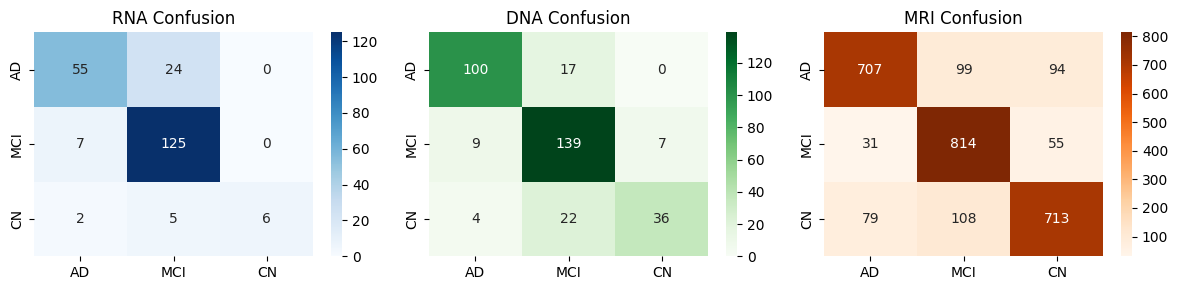


📈 Summary of Global Student Performance:


,Modality,Accuracy,F1-score
0,RNA,0.830357,0.823055
1,DNA,0.823353,0.819320
2,MRI,0.827407,0.826771


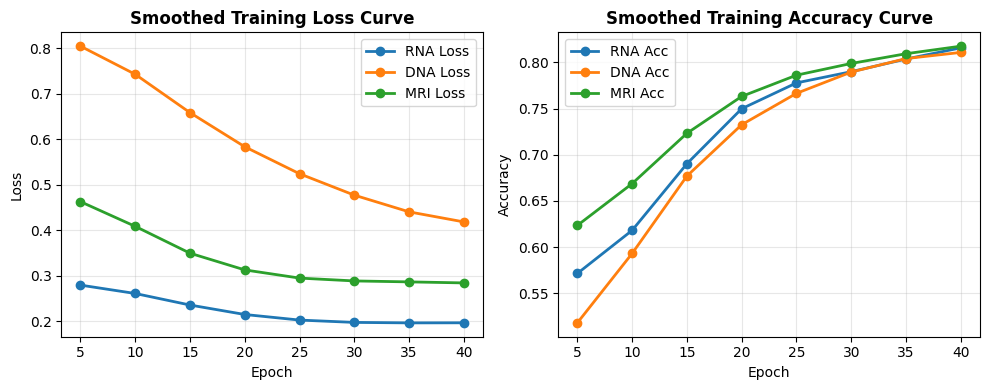

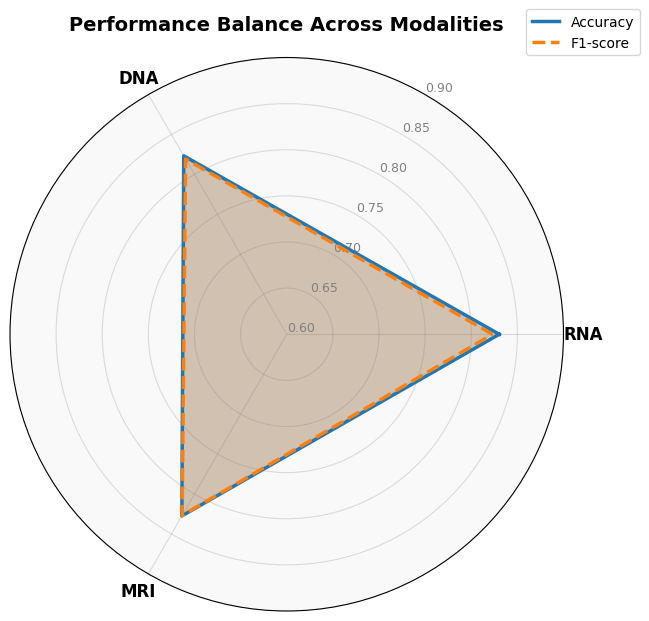

✅ Styled radar chart & curves saved to: /content/drive/MyDrive/5703/FL/outputs


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import os, random, gc, numpy as np, pandas as pd
from glob import glob
from PIL import Image
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
from math import pi
from scipy.ndimage import gaussian_filter1d

# ----------------------------
# 0. Config
# ----------------------------
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

DATA_RNA = "/content/drive/MyDrive/5703/RNA_cleaned.csv"
DATA_DNA = "/content/drive/MyDrive/5703/ADNI3_DNA_cleaned.csv"
DATA_MRI = "/content/drive/MyDrive/5703/FL/MRI/Sampled MRI"
N_CLASSES = 3


T_RNA, T_DNA, T_MRI = 3.0, 1.0, 8.0
ALPHA_RNA, ALPHA_DNA, ALPHA_MRI = 0.8, 0.7, 0.7
W_RNA, W_DNA, W_MRI = 0.4, 2.5, 1.5
EPOCHS_STUDENT = 40
LR_STUDENT = 3e-4
HIDDEN_DIM = 256

MRI_LR = 7.354e-5
MRI_DROPOUT = 0.2
MRI_IMG_SIZE = (224, 224)


# 1. RNA Client (teacher)
df_rna = pd.read_csv(DATA_RNA) # Load a CSV file into a pandas DataFrame (tabular data structure).
Xr = df_rna.drop(columns=["DIAGNOSIS", "subject_id"], errors='ignore') # Drop specified columns to remove identifiers or leakage features from the dataset.
yr = df_rna["DIAGNOSIS"].astype(int) # Select the target label column used for supervised learning.
le_rna = LabelEncoder() # Convert categorical labels into integer indices required by many classifiers.
yr_enc = le_rna.fit_transform(yr)

# Split data into train/test sets to estimate generalization on unseen samples.
Xr_train, Xr_test, yr_train, yr_test = train_test_split(Xr, yr_enc, test_size=0.3, stratify=yr_enc, random_state=SEED)

# Standardize features to zero-mean and unit-variance; helps many models converge stably.
sc_rna = StandardScaler().fit(Xr_train)
Xr_train = sc_rna.transform(Xr_train).astype(np.float32)
Xr_test = sc_rna.transform(Xr_test).astype(np.float32)

# Define a fully connected neural network (MLP) for RNA modality classification.
# This model progressively reduces dimensionality and applies batch normalization and dropout to prevent overfitting.
class RNA_MLP(nn.Module):
    def __init__(self, in_dim, n_classes):
        super().__init__()
        # Sequentially stack linear layers with normalization and non-linear activation.
        # Dropout is applied after each hidden layer to regularize the model and reduce co-adaptation of neurons.
        self.net = nn.Sequential(
            nn.Linear(in_dim,512), nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512,256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128,n_classes)
        )
    def forward(self,x): return self.net(x)

# Instantiate the RNA model and move it to the selected device (CPU/GPU).
rna_client = RNA_MLP(Xr_train.shape[1], N_CLASSES).to(device)

# Use Adam optimizer for efficient gradient-based optimization with adaptive learning rates.
opt_rna = torch.optim.Adam(rna_client.parameters(), lr=1e-3)

# Define the loss function: CrossEntropyLoss combines softmax + negative log-likelihood for multi-class classification.
ce = nn.CrossEntropyLoss()

# Model training loop
# Train for 12 epochs (complete passes over the training dataset).
# Each epoch computes gradients on the training set and updates parameters via backpropagation.
for ep in range(12):
    rna_client.train()
    # Set model to training mode (enables dropout and batch norm updates)
    # Forward pass: compute model predictions (logits) from training features.
    out = rna_client(torch.tensor(Xr_train, dtype=torch.float32, device=device))

    # Compute classification loss comparing predictions with ground-truth labels.
    loss = ce(out, torch.tensor(yr_train, dtype=torch.long, device=device))
    opt_rna.zero_grad(); loss.backward(); opt_rna.step()

rna_client.eval()
with torch.no_grad():
    # Compute model outputs (logits) on the test set.
    # Apply temperature-scaled softmax to produce "soft labels" — smoother probability distributions
    # that encode teacher model confidence across classes (used later for knowledge distillation).
    # Dividing logits by T_RNA > 1 flattens probabilities, revealing inter-class relationships.
    p_rna_soft = F.softmax(
        rna_client(torch.tensor(Xr_test, dtype=torch.float32, device=device)) / T_RNA, dim=1
    ).cpu().numpy()

del rna_client, opt_rna, out, loss
torch.cuda.empty_cache(); gc.collect()


# 2. DNA Client (teacher)

dna = pd.read_csv(DATA_DNA).drop(columns=["PTID","EXAMDATE","PHASE"], errors='ignore') # Load a CSV file into a pandas DataFrame (tabular data structure).
Xd = dna.drop(columns=["DIAGNOSIS"], errors='ignore').select_dtypes(include=[np.number])  # Drop specified columns to remove identifiers or leakage features from the dataset.
yd = dna["DIAGNOSIS"].astype(int)   # Convert categorical labels into integer indices required by many classifiers.
le_dna = LabelEncoder(); yd_enc = le_dna.fit_transform(yd)

# Split data into train/test sets to estimate generalization on unseen samples.
Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    Xd, yd_enc, test_size=0.3, stratify=yd_enc, random_state=SEED)

sc_dna = StandardScaler().fit(Xd_train)
Xd_train = sc_dna.transform(Xd_train)
Xd_test  = sc_dna.transform(Xd_test)

# PCA optimization.
# Train the estimator on the provided data (learn parameters from training set).
pca_dna = PCA(n_components=200, whiten=True, random_state=SEED).fit(Xd_train)
Xd_train = pca_dna.transform(Xd_train).astype(np.float32)
Xd_test  = pca_dna.transform(Xd_test ).astype(np.float32)

# SMOTE balancing.
# Apply Synthetic Minority Over-sampling Technique to address class imbalance by generating synthetic minority samples.
smote = SMOTE(random_state=SEED, sampling_strategy='not majority', k_neighbors=5)

# Improving the teacher model by balancing the training data.
# Fit a resampler on training data and produce a balanced dataset for model training.
Xd_train_res, yd_train_res = smote.fit_resample(Xd_train, yd_train)

# Random Forest: ensemble of trees with bagging+feature randomness; reduces variance and overfitting.
rf  = RandomForestClassifier(
    n_estimators=400, max_depth=10, class_weight="balanced_subsample", random_state=SEED
)

# XGBoost: gradient-boosted trees with regularization; strong performance on tabular data.
xgb = XGBClassifier(
    objective="multi:softprob", num_class=N_CLASSES, eval_metric="mlogloss",
    max_depth=8, learning_rate=0.05, n_estimators=300,
    subsample=0.9, colsample_bytree=0.9, random_state=SEED, n_jobs=-1
)
dna_client = VotingClassifier(estimators=[("rf", rf), ("xgb", xgb)], voting="soft", weights=[2,3])
dna_client.fit(Xd_train_res, yd_train_res)

# soft label
# Smooth the predicted probabilities to soften the labels.
# Return class probabilities, enabling calibrated decisions or threshold selection.
p_dna_raw  = dna_client.predict_proba(Xd_test)
p_dna_soft = np.exp(np.log(np.clip(p_dna_raw, 1e-12, 1.0)) / T_DNA)
p_dna_soft /= p_dna_soft.sum(axis=1, keepdims=True)

del dna_client, rf, xgb, Xd_train_res, yd_train_res
torch.cuda.empty_cache(); gc.collect()

# 3. MRI Client (teacher)
# Map clinical labels to integer class IDs.
# Keeping an explicit mapping avoids accidental label reordering by libraries and makes metrics reproducible.
has_nc = os.path.isdir(os.path.join(DATA_MRI, "NC"))
CLASS_MAP = {"AD":0,"MCI":1,"NC":2} if has_nc else {"AD":0,"MCI":1,"CN":2}


# Collect all image file paths under class-specific subfolders and build aligned label arrays.
# Folder layout is assumed to be: root/AD/*.png|jpg|jpeg|bmp, root/MCI/*..., root/CN/*...
def list_images(root, class_map):
    paths, labels = [], []
    for cname, cid in class_map.items():
        for e in ("png","jpg","jpeg","bmp"):
            files = glob(os.path.join(root, cname, f"*.{e}"))
            paths += files; labels += [cid]*len(files)

    # Use NumPy arrays for compatibility with scikit-learn utilities (e.g., train_test_split, stratify).
    return np.array(paths), np.array(labels, dtype=np.int64)

paths_all, labels_all = list_images(DATA_MRI, CLASS_MAP)

# Split data into train/test sets to estimate generalization on unseen samples.
# 'stratify' preserves the class distribution in both splits, which is important for imbalanced medical datasets.
# A fixed random_state (SEED) ensures reproducibility of the split.
paths_train, paths_test, ym_train, ym_test = train_test_split(
    paths_all, labels_all, test_size=0.3, stratify=labels_all, random_state=SEED)

# Define train-time transforms: convert to 1-channel grayscale, resize to a fixed spatial size,
# add light augmentation (RandomHorizontalFlip) to improve robustness, and normalize to zero-centered scale.
# Normalization with mean=0.5, std=0.5 maps raw [0,1] tensors to ~[-1,1], which often stabilizes CNN training.
tf_train = transforms.Compose([
    transforms.Grayscale(1), transforms.Resize(MRI_IMG_SIZE),
    transforms.RandomHorizontalFlip(), transforms.ToTensor(),
    transforms.Normalize([0.5],[0.5])
])

# Define eval-time transforms: the same preprocessing *without* random augmentation to ensure deterministic evaluation.
tf_eval = transforms.Compose([
    transforms.Grayscale(1), transforms.Resize(MRI_IMG_SIZE),
    transforms.ToTensor(), transforms.Normalize([0.5],[0.5])
])

# Minimal PyTorch Dataset that reads images lazily by path.
# Storing paths instead of full images reduces memory pressure; PIL loading + transforms happen on-the-fly in __getitem__.
class MRIDataset(Dataset):
    def __init__(self, paths, labels, tfm):
        self.paths, self.labels, self.tfm = list(paths), list(labels), tfm
    def __len__(self): return len(self.paths)
    def __getitem__(self, i):
        return self.tfm(Image.open(self.paths[i]).convert("L")), self.labels[i]

ds_mt = MRIDataset(paths_train, ym_train, tf_train)
ds_ms = MRIDataset(paths_test , ym_test , tf_eval)
dl_mt = DataLoader(ds_mt, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
dl_ms = DataLoader(ds_ms, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

# A compact CNN for 128x128 single-channel images:
# - Three Conv blocks: (Conv -> ReLU -> MaxPool), halving spatial dims each time: 128->64->32->16.
# - Classifier head: Flatten -> Dropout (regularization) -> Linear -> ReLU -> Dropout -> Linear to logits.
class MRI_CNN(nn.Module):
    def __init__(self, n_classes=3, dropout=0.2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 96, 3, padding=1), nn.BatchNorm2d(96), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(96, 48, 3, padding=1), nn.BatchNorm2d(48), nn.ReLU(), nn.MaxPool2d(2)
        )

        # At this point, feature map is [B, 64, 16, 16] => 64*16*16 features after flattening.
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Linear(48*28*28, 192), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(192, n_classes)
        )
    def forward(self, x): return self.classifier(self.features(x))

mri_client = MRI_CNN(N_CLASSES, dropout=MRI_DROPOUT).to(device)
opt_mri = torch.optim.Adam(mri_client.parameters(), lr=MRI_LR)
ce = nn.CrossEntropyLoss()

# Training loop (10 epochs):
# - model.train(): enables dropout and updates BatchNorm stats (none here but good practice).
# - Each batch: forward -> CE loss -> zero_grad -> backward -> step.
# Note: 'ce' must be defined previously (e.g., nn.CrossEntropyLoss()) and expects logits + int64 labels.

for ep in range(10):
    mri_client.train(); running = 0.0
    for xb,yb in dl_mt:
        xb, yb = xb.to(device), torch.tensor(yb, dtype=torch.long, device=device)
        out = mri_client(xb); loss = ce(out,yb)
        opt_mri.zero_grad(); loss.backward(); opt_mri.step(); running += loss.item()

# --- Generate soft labels for 30% test ---
# For knowledge distillation: produce temperature-scaled soft probabilities to convey inter-class similarities.
# model.eval() disables dropout and uses running stats; torch.no_grad() cuts memory and speeds up inference.
mri_client.eval(); p_mri=[]
with torch.no_grad():
    for xb,_ in dl_ms:
        xb = xb.to(device)
        p_mri.append(F.softmax(mri_client(xb)/T_MRI, dim=1).cpu().numpy())
p_mri_soft = np.concatenate(p_mri)

del mri_client, opt_mri
torch.cuda.empty_cache(); gc.collect()

# 4. Global Student
# A three-tower student model: each modality has its own encoder (RNA/DNA: MLP; MRI: small CNN).
# The design lets the student learn modality-specific representations while sharing the same loss shaping (KD + CE).
class ThreeTowerGlobal(nn.Module):
    def __init__(self, dim_rna, dim_dna, hidden_dim, n_classes):
        super().__init__()
        # RNA encoder: single Linear -> ReLU -> Dropout.
        self.enc_rna = nn.Sequential(
            nn.Linear(dim_rna, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )
        # DNA encoder: symmetric to RNA to keep inductive bias similar across tabular modalities.
        self.enc_dna = nn.Sequential(
            nn.Linear(dim_dna, hidden_dim), nn.BatchNorm1d(hidden_dim),
            nn.ReLU(), nn.Dropout(0.3)
        )
        # MRI encoder: light CNN to extract spatial features from 1-channel 2D inputs;
        # three conv blocks with pooling reduce 128x128 -> 16x16, then flatten to hidden_dim.
        self.enc_mri = nn.Sequential(
            nn.Conv2d(1,64,3,padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,96,3,padding=1), nn.BatchNorm2d(96), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(96,48,3,padding=1), nn.BatchNorm2d(48), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(), nn.Linear(48*28*28, hidden_dim), nn.ReLU(), nn.Dropout(0.3)
        )
        # Modality-specific classification heads (logits). Keeping separate heads
        # avoids negative transfer when modalities have different feature statistics.
        self.head_rna = nn.Linear(hidden_dim, n_classes)
        self.head_dna = nn.Linear(hidden_dim, n_classes)
        self.head_mri = nn.Linear(hidden_dim, n_classes)
    # The forward API takes a modality flag and routes inputs through the corresponding encoder + head.
    # This makes a single student support KD from multiple teachers with heterogeneous inputs.
    def forward(self, x, modality):
        if   modality=="rna": return self.head_rna(self.enc_rna(x))
        elif modality=="dna": return self.head_dna(self.enc_dna(x))
        elif modality=="mri": return self.head_mri(self.enc_mri(x))
        else: raise ValueError("modality must be in {rna,dna,mri}")

# Knowledge Distillation loss:
# - teacher_probs are *probabilities* (soft labels), typically softmax(logits / T) from the teacher.
# - student_logits are raw logits; we apply log_softmax(student/T) and use KL divergence.
# - alpha trades off between KD (soft-target matching) and CE (hard labels). T^2 keeps gradients scale-invariant w.r.t. T.
def kd_loss(student_logits, teacher_probs, true_labels, T=3.0, alpha=0.7):
    log_p_s = F.log_softmax(student_logits / T, dim=1)
    loss_kd = F.kl_div(log_p_s, teacher_probs, reduction="batchmean") * (T**2)
    loss_ce = F.cross_entropy(student_logits, true_labels)
    return alpha * loss_kd + (1 - alpha) * loss_ce

# tensors
Xr_t = torch.tensor(Xr_test, dtype=torch.float32, device=device)
Xd_t = torch.tensor(Xd_test, dtype=torch.float32, device=device)
yr_t = torch.tensor(yr_test, dtype=torch.long, device=device)
yd_t = torch.tensor(yd_test, dtype=torch.long, device=device)
pr_t = torch.tensor(p_rna_soft, dtype=torch.float32, device=device)
pd_t = torch.tensor(p_dna_soft, dtype=torch.float32, device=device)
ym_t = torch.tensor(ym_test, dtype=torch.long, device=device)
pm_t = torch.tensor(p_mri_soft, dtype=torch.float32, device=device)

dl_mri_test = DataLoader(ds_ms, batch_size=8, shuffle=False, num_workers=0, pin_memory=True)
accum_steps = 4

student = ThreeTowerGlobal(Xr_t.shape[1], Xd_t.shape[1], HIDDEN_DIM, N_CLASSES).to(device)
opt = torch.optim.Adam(student.parameters(), lr=LR_STUDENT)

# Store the loss and accuracy values ​​for each training session.
rna_losses, dna_losses, mri_losses = [], [], []
rna_accs, dna_accs, mri_accs = [], [], []

for ep in range(1, EPOCHS_STUDENT+1):
    student.train()
    opt.zero_grad(set_to_none=True)
    # RNA KD: student(RNA) vs RNA-teacher soft labels on the same examples; CE uses true labels for stability.
    loss_r = kd_loss(student(Xr_t,"rna"), pr_t, yr_t, T=T_RNA, alpha=ALPHA_RNA)
    # DNA KD: analogous to RNA.
    loss_d = kd_loss(student(Xd_t,"dna"), pd_t, yd_t, T=T_DNA, alpha=ALPHA_DNA)
    total_static = W_RNA*loss_r + W_DNA*loss_d
    total_static.backward()

    loss_m_running = 0.0
    start = 0
    for i, (xb, _) in enumerate(dl_mri_test):
        xb = xb.to(device, non_blocking=True)
        sl = slice(start, start + xb.size(0))
        # Important: pm_t[sl] must be a valid probability distribution per row (sum≈1), with shape [B, n_classes].
        # If pm_t came from softmax(logits/T), this is satisfied; passing raw logits would break the KL (must be probs).
        logits_m = student(xb, "mri")
        l_m = kd_loss(logits_m, pm_t[sl], ym_t[sl], T=T_MRI, alpha=ALPHA_MRI)
        (W_MRI * l_m / accum_steps).backward()
        loss_m_running += l_m.item()
        start += xb.size(0)
        if (i + 1) % accum_steps == 0:
            opt.step(); opt.zero_grad(set_to_none=True)
            torch.cuda.empty_cache(); gc.collect()
        del xb, logits_m, l_m
        torch.cuda.empty_cache()
    if (len(dl_mri_test) % accum_steps) != 0:
        opt.step(); opt.zero_grad(set_to_none=True)

    # Performance is recorded every 5 rounds.
    if ep % 5 == 0:
        student.eval()
        with torch.no_grad():
            rna_pred = student(Xr_t,"rna").argmax(1)
            dna_pred = student(Xd_t,"dna").argmax(1)
            mri_pred = torch.cat([student(xb.to(device),"mri").argmax(1) for xb,_ in dl_mri_test])
            acc_r = (rna_pred == yr_t).float().mean().item()
            acc_d = (dna_pred == yd_t).float().mean().item()
            acc_m = (mri_pred == ym_t).float().mean().item()
        rna_accs.append(acc_r); dna_accs.append(acc_d); mri_accs.append(acc_m)
        rna_losses.append(loss_r.item()); dna_losses.append(loss_d.item()); mri_losses.append(loss_m_running/len(dl_mri_test))
        print(f"[Ep {ep:02d}] RNA={loss_r.item():.4f} DNA={loss_d.item():.4f} MRI(avg)={loss_m_running/len(dl_mri_test):.4f} "
              f"| Acc(R/D/M)={acc_r:.3f}/{acc_d:.3f}/{acc_m:.3f}")

# Optional: DNA-only Fine-Tuning
dna_params = list(student.enc_dna.parameters()) + list(student.head_dna.parameters())
for p in student.parameters(): p.requires_grad = False
for p in dna_params: p.requires_grad = True

opt_dna = torch.optim.Adam(dna_params, lr=LR_STUDENT * 0.5)
for ep in range(3):
    opt_dna.zero_grad(set_to_none=True)
    logits_d = student(Xd_t, "dna")
    loss_d_mf = kd_loss(logits_d, pd_t, yd_t, T=T_DNA, alpha=ALPHA_DNA) * W_DNA
    loss_d_mf.backward(); opt_dna.step()
    print(f"[DNA microFT] ep{ep+1}: {loss_d_mf.item():.4f}")
for p in student.parameters(): p.requires_grad = True

# 5. Evaluation
student.eval()
with torch.no_grad():
    y_pred_rna = student(Xr_t,"rna").argmax(1).cpu().numpy()
    y_pred_dna = student(Xd_t,"dna").argmax(1).cpu().numpy()

cm_rna = confusion_matrix(yr_test, y_pred_rna)
print("\n📊 RNA Branch Test Performance (Global Model)")
print(classification_report(yr_test, y_pred_rna, digits=3))
plt.figure(figsize=(12,3))
plt.subplot(1,3,1)
sns.heatmap(cm_rna, annot=True, fmt="d", cmap="Blues",
            xticklabels=["AD","MCI","CN"], yticklabels=["AD","MCI","CN"])
plt.title("RNA Confusion")

cm_dna = confusion_matrix(yd_test, y_pred_dna)
print("\n🧬 DNA Branch Test Performance (Global Model)")
print(classification_report(yd_test, y_pred_dna, digits=3))
plt.subplot(1,3,2)
sns.heatmap(cm_dna, annot=True, fmt="d", cmap="Greens",
            xticklabels=["AD","MCI","CN"], yticklabels=["AD","MCI","CN"])
plt.title("DNA Confusion")

pred_mri, true_mri = [], []
with torch.no_grad():
    for xb, yb in DataLoader(ds_ms, batch_size=32, shuffle=False, num_workers=1):
        xb = xb.to(device)
        out = student(xb, "mri")
        pred_mri.append(out.argmax(1).cpu().numpy())
        true_mri.append(np.array(yb))
pred_mri = np.concatenate(pred_mri)
true_mri = np.concatenate(true_mri)

cm_mri = confusion_matrix(true_mri, pred_mri)
print("\n🧠 MRI Branch Test Performance (Global Model)")
print(classification_report(true_mri, pred_mri, digits=3))
plt.subplot(1,3,3)
sns.heatmap(cm_mri, annot=True, fmt="d", cmap="Oranges",
            xticklabels=["AD","MCI","CN"], yticklabels=["AD","MCI","CN"])
plt.title("MRI Confusion")
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=300)
plt.show()

# 6. Summary Table
acc_rna = accuracy_score(yr_test, y_pred_rna)
f1_rna  = f1_score(yr_test, y_pred_rna, average='weighted')
acc_dna = accuracy_score(yd_test, y_pred_dna)
f1_dna  = f1_score(yd_test, y_pred_dna, average='weighted')
acc_mri = accuracy_score(true_mri, pred_mri)
f1_mri  = f1_score(true_mri, pred_mri, average='weighted')

summary_df = pd.DataFrame({
    "Modality": ["RNA", "DNA", "MRI"],
    "Accuracy": [acc_rna, acc_dna, acc_mri],
    "F1-score": [f1_rna, f1_dna, f1_mri]
})
print("\n📈 Summary of Global Student Performance:")
display(summary_df.style.background_gradient(
    subset=["Accuracy", "F1-score"], cmap="viridis"
).format({"Accuracy": "{:.6f}", "F1-score": "{:.6f}"}))

# Visualization with Smoothed Curves + Radar Chart
save_dir = "/content/drive/MyDrive/5703/FL/outputs"
os.makedirs(save_dir, exist_ok=True)

# Loss & Accuracy Curves (Smoothed)
epochs_plot = np.arange(5, EPOCHS_STUDENT + 1, 5)
sigma_val = 1.2

loss_rna_smooth = gaussian_filter1d(rna_losses, sigma=sigma_val)
loss_dna_smooth = gaussian_filter1d(dna_losses, sigma=sigma_val)
loss_mri_smooth = gaussian_filter1d(mri_losses, sigma=sigma_val)

acc_rna_smooth = gaussian_filter1d(rna_accs, sigma=sigma_val)
acc_dna_smooth = gaussian_filter1d(dna_accs, sigma=sigma_val)
acc_mri_smooth = gaussian_filter1d(mri_accs, sigma=sigma_val)

plt.figure(figsize=(10,4))
# Loss
plt.subplot(1,2,1)
plt.plot(epochs_plot, loss_rna_smooth, '-o', label='RNA Loss', linewidth=2)
plt.plot(epochs_plot, loss_dna_smooth, '-o', label='DNA Loss', linewidth=2)
plt.plot(epochs_plot, loss_mri_smooth, '-o', label='MRI Loss', linewidth=2)
plt.title("Smoothed Training Loss Curve", fontsize=12, weight='bold')
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3)

# Accuracy
plt.subplot(1,2,2)
plt.plot(epochs_plot, acc_rna_smooth, '-o', label='RNA Acc', linewidth=2)
plt.plot(epochs_plot, acc_dna_smooth, '-o', label='DNA Acc', linewidth=2)
plt.plot(epochs_plot, acc_mri_smooth, '-o', label='MRI Acc', linewidth=2)
plt.title("Smoothed Training Accuracy Curve", fontsize=12, weight='bold')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f"{save_dir}/loss_accuracy_curves_smoothed.png", dpi=400)
plt.show()

# Radar Chart
modalities = ["RNA", "DNA", "MRI"]
values_acc = [acc_rna, acc_dna, acc_mri]
values_f1  = [f1_rna, f1_dna, f1_mri]


angles = np.linspace(0, 2*np.pi, len(modalities), endpoint=False).tolist()
values_acc += values_acc[:1]
values_f1  += values_f1[:1]
angles += angles[:1]

plt.figure(figsize=(6.5,6.5))
ax = plt.subplot(111, polar=True)

# Plot Accuracy (solid line)
ax.plot(angles, values_acc, color='#1f77b4', linewidth=2.5, linestyle='-', label="Accuracy")
ax.fill(angles, values_acc, color='#1f77b4', alpha=0.25)


# Plot F1-score (dashed line)
ax.plot(angles, values_f1, color='#ff7f0e', linewidth=2.5, linestyle='--', label="F1-score")
ax.fill(angles, values_f1, color='#ff7f0e', alpha=0.25)

# Style radar chart
ax.set_thetagrids(np.degrees(angles[:-1]), modalities, fontsize=12, fontweight='bold')
ax.set_rlabel_position(180/len(modalities))
ax.set_ylim(0.6, 0.9)
ax.set_yticks(np.arange(0.6, 0.91, 0.05))
ax.set_yticklabels([f"{x:.2f}" for x in np.arange(0.6, 0.91, 0.05)], fontsize=9, color='gray')
ax.spines['polar'].set_visible(True)
ax.grid(True, linestyle='-', color='gray', alpha=0.25)
ax.set_facecolor('#f9f9f9')

# Add title and legend
plt.title("Performance Balance Across Modalities", fontsize=14, fontweight='bold', pad=20)
plt.legend(loc="upper right", bbox_to_anchor=(1.15, 1.10), frameon=True)
plt.tight_layout()
plt.savefig(f"{save_dir}/radar_chart_styled.png", dpi=400, bbox_inches='tight')
plt.show()

print(f"✅ Styled radar chart & curves saved to: {save_dir}")
